# RansomSense
## Notebook 4: Machine Learning Model Training

### Objective

This notebook focuses on training machine learning models capable of predicting the severity of ransomware attacks.

Several regression algorithms are trained and evaluated using common performance metrics.

The model with the best predictive performance will be selected for deployment in the RansomSense application.

### Models

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

### Evaluation Metrics

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [1]:
import pandas as pd
import numpy as np

import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/processed/cleaned_ransomware_dataset.csv")

df.head()

,Attack_ID,Company_Name,Industry,Country,Attack_Date,Ransomware_Group,Attack_Vector,Ransom_Amount_USD,Payment_Status,Data_Exfiltration,Downtime_Days,Records_Affected,Estimated_Total_Loss_USD,Severity_Score
0,RA-100000,Mcdonald-Smith,Government,United Kingdom,2024-08-02,BlackCat,Drive-by Download,938912,Paid,No,2,2307213,1462487,3.55
1,RA-100001,Lopez and Sons,Transportation,Japan,2021-03-07,LockBit,Credential Theft,254957,Not Paid,No,6,1834168,752882,2.99
2,RA-100002,Anthony Group,Healthcare,United Kingdom,2022-03-28,Ryuk,Malicious Attachment,3773238,Negotiated,Yes,38,2333732,5480736,11.81
3,RA-100003,"Rodriguez, Romero and Mills",Finance,Australia,2022-03-17,Maze,Credential Theft,2828559,Negotiated,Yes,7,778108,3635324,4.66
4,RA-100004,Brown LLC,Technology,South Africa,2025-02-03,Hive,Malicious Attachment,3858935,Negotiated,Yes,35,1047217,5803128,10.16


# Feature Selection

The same features selected during preprocessing are used to train the severity prediction model.

This ensures consistency between preprocessing and model training.

In [3]:
SEVERITY_FEATURES = [
    "Industry",
    "Country",
    "Attack_Date",
    "Ransomware_Group",
    "Attack_Vector",
    "Ransom_Amount_USD"
]

X = df[SEVERITY_FEATURES]

y = df["Severity_Score"]

In [4]:
X["Attack_Date"] = pd.to_datetime(X["Attack_Date"])

X["Attack_Year"] = X["Attack_Date"].dt.year
X["Attack_Month"] = X["Attack_Date"].dt.month
X["Attack_Day"] = X["Attack_Date"].dt.day
X["Attack_DayOfWeek"] = X["Attack_Date"].dt.dayofweek

X = X.drop("Attack_Date", axis=1)

In [5]:
categorical_features = X.select_dtypes(include="object").columns

numerical_features = X.select_dtypes(include=["int64","float64"]).columns

C:\Users\hlaku\AppData\Local\Temp\ipykernel_6968\701655839.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [8]:
X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

# Model Training

Multiple regression algorithms are trained and evaluated to determine which model best predicts ransomware attack severity.

In [9]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [10]:
results = []

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

    trained_models[name] = model

In [11]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R² Score"
    ]
)

results_df.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
0,Linear Regression,2.577104,3.046866,0.163740
3,Gradient Boosting,2.592035,3.064047,0.154282
2,Random Forest,2.642077,3.168571,0.095598
1,Decision Tree,3.580110,4.384518,-0.731723


In [12]:
best_model_name = results_df.sort_values(
    by="R² Score",
    ascending=False
).iloc[0]["Model"]

best_model = trained_models[best_model_name]

print(best_model_name)

Linear Regression


In [13]:
joblib.dump(
    best_model,
    "../models/severity_model.pkl"
)

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']

In [14]:
predictions = best_model.predict(X_test)

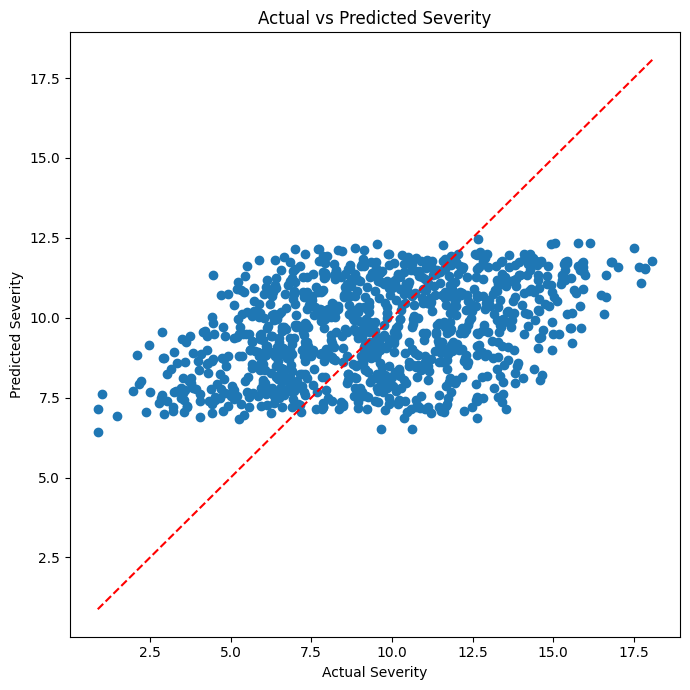

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Severity")

plt.ylabel("Predicted Severity")

plt.title("Actual vs Predicted Severity")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.tight_layout()

plt.savefig(
    "../images/actual_vs_predicted.png",
    dpi=300
)

plt.show()

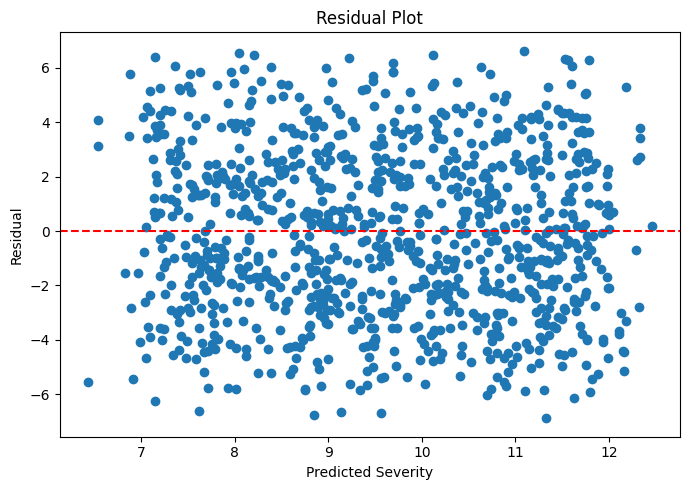

In [16]:
residuals = y_test - predictions

plt.figure(figsize=(7,5))

plt.scatter(
    predictions,
    residuals
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Severity")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.tight_layout()

plt.savefig(
    "../images/residual_plot.png",
    dpi=300
)

plt.show()

In [17]:
if hasattr(best_model, "feature_importances_"):

    feature_names = preprocessor.get_feature_names_out()

    importance = pd.Series(
        best_model.feature_importances_,
        index=feature_names
    )

    importance = importance.sort_values(
        ascending=False
    ).head(15)

    plt.figure(figsize=(10,6))

    importance.sort_values().plot(kind="barh")

    plt.title("Top 15 Important Features")

    plt.tight_layout()

    plt.savefig(
        "../images/feature_importance.png",
        dpi=300
    )

    plt.show()

# Conclusion

Four regression models were successfully trained and evaluated.

The models were compared using MAE, RMSE, and R² Score.

The best-performing model was selected based on its predictive performance and saved for future deployment.

The next notebook will focus on evaluating the selected model in greater detail and interpreting its predictions using Explainable AI techniques.